# Inital Exploratory Data Analysis

**NUS Industry 4.0 Capstone — 3D Bin Packing / Cartonization**

Initial EDA of the 2,000 iHub reference request/response records. The objective is to understand order complexity, box selection, packing constraints, utilization and latency before building our own solver.

In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 5)

candidates = [Path("../data/raw/data_sample_v1.json"), Path("data/raw/data_sample_v1.json"), Path("data_sample_v1.json")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place data_sample_v1.json in data/raw/ or next to this notebook.")
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)
print(f"Loaded {len(raw):,} orders from {DATA_PATH}")

Loaded 2,000 orders from ..\data\raw\data_sample_v1.json


## 1. What does the original data look like?

The source is nested JSON. For orientation, this first table flattens the first five orders so each row represents one input item line, together with the reference box selection and response information.

In [4]:
rows=[]
for record in raw[:5]:
    inp, out = record["input"], record["output"]
    boxes = out["Data"]["BinsPacked"]
    selected = ", ".join(b["Code"] for b in boxes)
    fill = ", ".join(f'{b["UsedSpace"]:.1f}%' for b in boxes)
    for item in inp["Items"]["ItemsList"]:
        rows.append({"OrderId":inp["OrderId"],"ItemCode":item["Code"],"Length_mm":item["Length"],"Width_mm":item["Width"],"Height_mm":item["Height"],"Weight_kg":item["Weight"],"UOM":item["UOM"],"VerticalRotation":item["VerticalRotation"],"Quantity":item["Quantity"],"SelectedBox":selected,"UsedSpace":fill,"Status":out["StatusMessage"],"Latency_ms":record["latency_ms"]})
original_preview_df=pd.DataFrame(rows)
display(original_preview_df)

,OrderId,ItemCode,Length_mm,Width_mm,Height_mm,Weight_kg,UOM,VerticalRotation,Quantity,SelectedBox,UsedSpace,Status,Latency_ms
0,1,63,140,80,116.00,0.28,EA,1,1,Box3,43.6%,Success,232.59
1,1,70,160,80,120.00,0.19,EA,1,1,Box3,43.6%,Success,232.59
2,1,66,55,55,110.00,0.13,EA,1,1,Box3,43.6%,Success,232.59
3,1,75,70,65,115.00,0.16,EA,1,1,Box3,43.6%,Success,232.59
4,2,30,245,40,125.00,0.20,BOX,1,2,Box5,54.5%,Success,217.12
5,2,132,80,80,210.00,0.65,EA,0,1,Box5,54.5%,Success,217.12
6,2,131,60,60,145.00,0.28,EA,1,2,Box5,54.5%,Success,217.12
7,2,9,255,40,192.00,1.25,SET,1,1,Box5,54.5%,Success,217.12
8,2,63,140,80,116.00,0.28,EA,1,1,Box5,54.5%,Success,217.12
9,2,64,55,55,115.00,0.12,EA,1,1,Box5,54.5%,Success,217.12


## 2. Build analysis tables

In [5]:
order_rows=[]; item_rows=[]; bin_rows=[]
for r in raw:
    inp,out=r["input"],r["output"]; oid=inp["OrderId"]; items=inp["Items"]["ItemsList"]; packed=out["Data"]["BinsPacked"]
    qty=sum(i["Quantity"] for i in items)
    vol=sum(i["Length"]*i["Width"]*i["Height"]*i["Quantity"] for i in items)
    wt=sum(i["Weight"]*i["Quantity"] for i in items)
    upright=sum(i["Quantity"] for i in items if i["VerticalRotation"]==0)
    order_rows.append({"order_id":oid,"sku_lines":len(items),"item_qty":qty,"total_volume_l":vol/1_000_000,"total_weight_kg":wt,"upright_only_qty":upright,"has_upright_only":upright>0,"bins_used":len(packed),"latency_ms":r["latency_ms"],"success":out["StatusCode"]==0,"not_packed":len(out["Data"]["NotPackedItems"])})
    for i in items:
        item_rows.append({"order_id":oid,"code":i["Code"],"length_mm":i["Length"],"width_mm":i["Width"],"height_mm":i["Height"],"weight_kg":i["Weight"],"uom":i["UOM"],"vertical_rotation":i["VerticalRotation"],"quantity":i["Quantity"]})
    for b in packed:
        bin_rows.append({"order_id":oid,"bin_code":b["Code"],"used_space_pct":b["UsedSpace"],"item_qty_in_bin":sum(i["Quantity"] for i in b["Items"]),"packed_weight_kg":sum(i["Weight"]*i["Quantity"] for i in b["Items"])})
orders_df=pd.DataFrame(order_rows); items_df=pd.DataFrame(item_rows); packed_bins_df=pd.DataFrame(bin_rows)
print(f"Orders: {len(orders_df):,} | SKU lines: {len(items_df):,} | Packed boxes: {len(packed_bins_df):,}")

Orders: 2,000 | SKU lines: 8,031 | Packed boxes: 2,134


## 3. Baseline KPIs

In [6]:
kpis=pd.Series({"Orders":len(orders_df),"Successful orders":int(orders_df.success.sum()),"Orders with unpacked items":int((orders_df.not_packed>0).sum()),"Unique item codes":items_df.code.nunique(),"Physical item quantity":int(items_df.quantity.sum()),"Average physical items/order":orders_df.item_qty.mean(),"Median physical items/order":orders_df.item_qty.median(),"Orders with upright-only items":int(orders_df.has_upright_only.sum()),"Average boxes/order":orders_df.bins_used.mean(),"Median latency (ms)":orders_df.latency_ms.median()})
display(kpis.to_frame("Value"))

,Value
Orders,"2,000.00"
Successful orders,"2,000.00"
Orders with unpacked items,0.00
Unique item codes,150.00
Physical item quantity,"15,103.00"
Average physical items/order,7.55
Median physical items/order,6.00
Orders with upright-only items,727.00
Average boxes/order,1.07
Median latency (ms),216.47


## 4. Order complexity

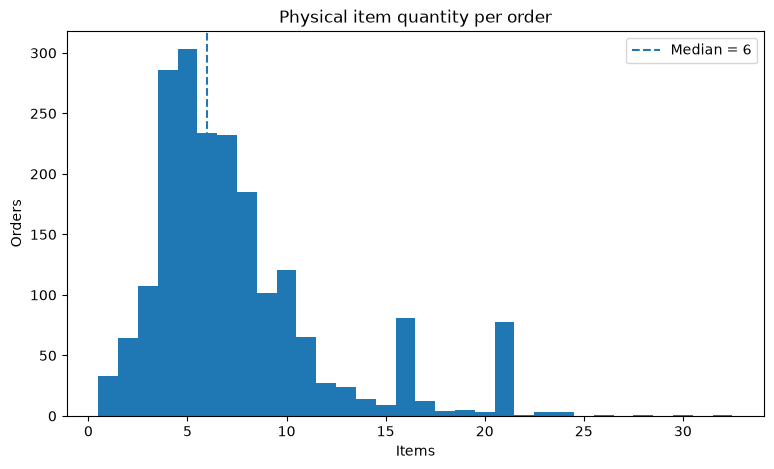

In [7]:
fig,ax=plt.subplots(); ax.hist(orders_df.item_qty,bins=np.arange(orders_df.item_qty.min(),orders_df.item_qty.max()+2)-0.5); ax.axvline(orders_df.item_qty.median(),linestyle="--",label=f"Median = {orders_df.item_qty.median():.0f}"); ax.set(title="Physical item quantity per order",xlabel="Items",ylabel="Orders"); ax.legend(); plt.show()

## 5. Primary objective: number of boxes used

,orders,percent
bins_used,,
1,1868,93.40
2,130,6.50
3,2,0.10


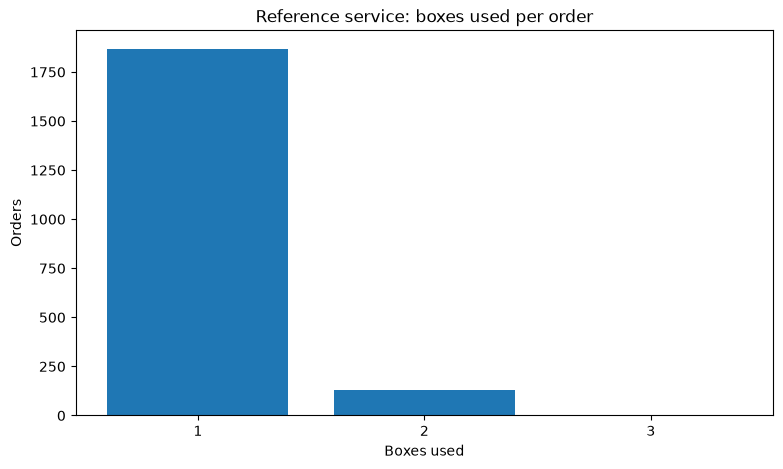

In [8]:
s=orders_df.bins_used.value_counts().sort_index(); display(pd.DataFrame({"orders":s,"percent":s/len(orders_df)*100})); fig,ax=plt.subplots(); ax.bar(s.index.astype(str),s.values); ax.set(title="Reference service: boxes used per order",xlabel="Boxes used",ylabel="Orders"); plt.show()

## 6. Box selection and utilization

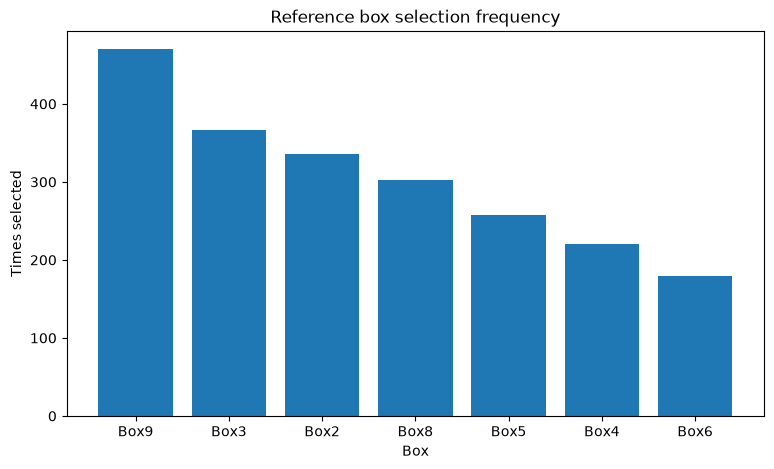

,count,mean,median,min,max
bin_code,,,,,
Box2,336,40.80,42.54,5.10,90.66
Box3,366,45.94,45.16,19.52,87.79
Box4,221,51.39,52.17,15.38,74.72
Box5,258,55.01,55.71,24.71,74.17
Box6,180,59.96,60.75,40.35,84.49
Box8,303,46.89,46.89,9.40,85.37
Box9,470,60.35,60.61,15.88,97.11


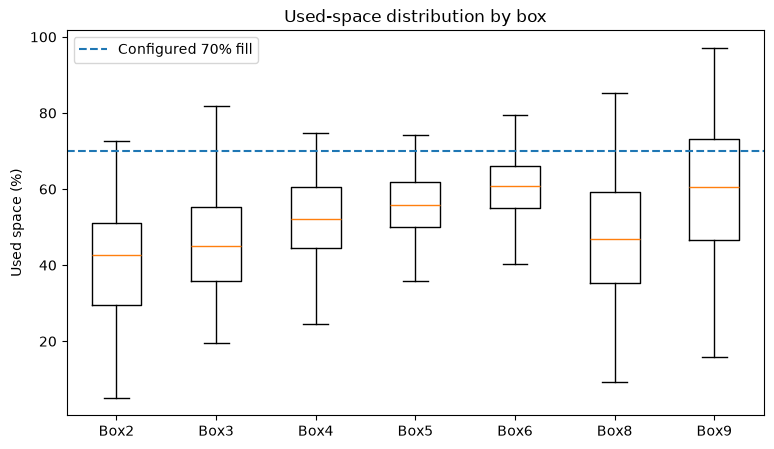

In [9]:
usage=packed_bins_df.bin_code.value_counts(); fig,ax=plt.subplots(); ax.bar(usage.index,usage.values); ax.set(title="Reference box selection frequency",xlabel="Box",ylabel="Times selected"); plt.show()

summary=packed_bins_df.groupby("bin_code").used_space_pct.agg(["count","mean","median","min","max"]); display(summary)
order=summary.index.tolist(); fig,ax=plt.subplots(); ax.boxplot([packed_bins_df.loc[packed_bins_df.bin_code==b,"used_space_pct"] for b in order],tick_labels=order,showfliers=False); ax.axhline(70,linestyle="--",label="Configured 70% fill"); ax.set(title="Used-space distribution by box",ylabel="Used space (%)"); ax.legend(); plt.show()

### 70% fill requirement

The README specifies `BinMaxFillCheckMinItemQty = 6` and `BinMaxFillPct = 70`. Some historical reference outputs exceed 70%, which suggests this is likely a newer usability requirement for our solver rather than behaviour that must be copied from every historical result. The intent is to leave enough free space so packers do not need extremely tight “Tetris-like” arrangements.

## 7. Rotation and weight constraints

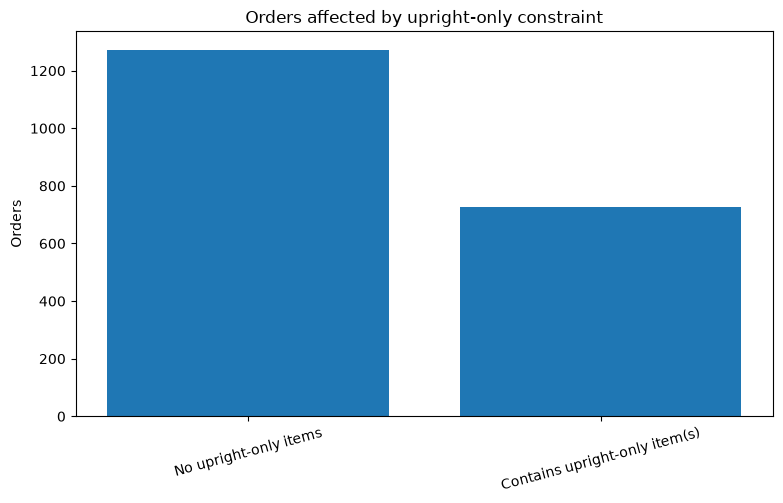

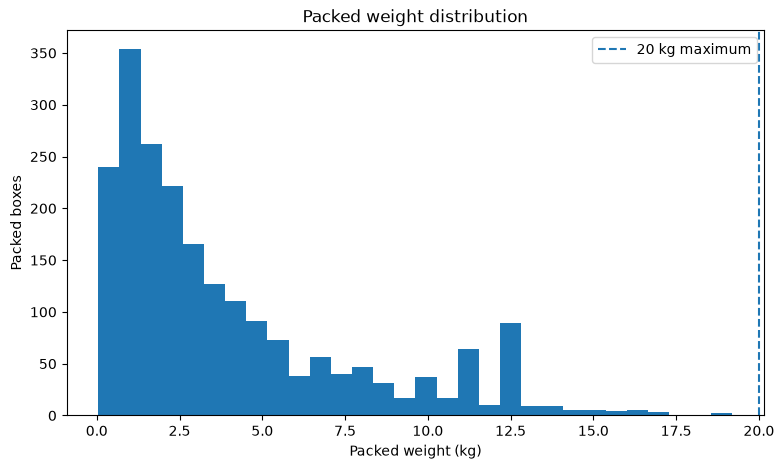

In [10]:
rot=pd.DataFrame({"Order type":["No upright-only items","Contains upright-only item(s)"],"Orders":[int((~orders_df.has_upright_only).sum()),int(orders_df.has_upright_only.sum())]}); fig,ax=plt.subplots(); ax.bar(rot["Order type"],rot["Orders"]); ax.set(title="Orders affected by upright-only constraint",ylabel="Orders"); ax.tick_params(axis="x",rotation=15); plt.show()

fig,ax=plt.subplots(); ax.hist(packed_bins_df.packed_weight_kg,bins=30); ax.axvline(20,linestyle="--",label="20 kg maximum"); ax.set(title="Packed weight distribution",xlabel="Packed weight (kg)",ylabel="Packed boxes"); ax.legend(); plt.show()

## 8. Latency

,latency_ms
count,"2,000.00"
mean,298.06
std,290.04
min,164.91
50%,216.47
90%,430.59
95%,517.39
99%,"1,884.74"
max,"4,195.27"


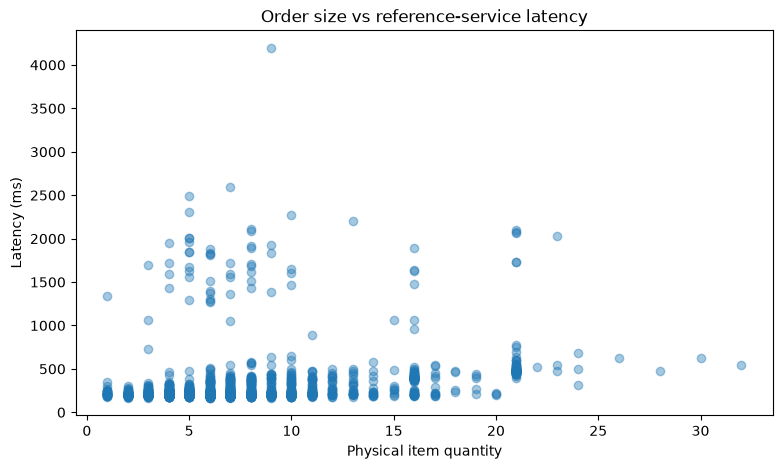

In [11]:
display(orders_df.latency_ms.describe(percentiles=[.5,.9,.95,.99]).to_frame("latency_ms")); fig,ax=plt.subplots(); ax.scatter(orders_df.item_qty,orders_df.latency_ms,alpha=.4); ax.set(title="Order size vs reference-service latency",xlabel="Physical item quantity",ylabel="Latency (ms)"); plt.show()

## 9. Multi-box orders: stress-test subset

Multi-box orders: 132 (6.6%)


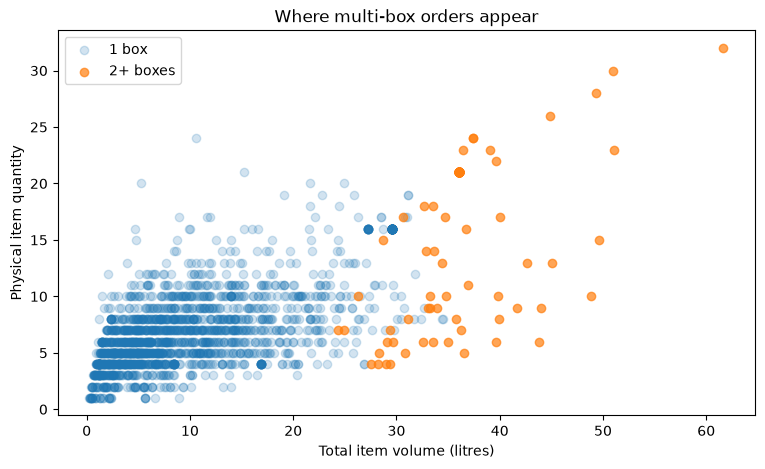

,order_id,sku_lines,item_qty,total_volume_l,total_weight_kg,upright_only_qty,has_upright_only,bins_used,latency_ms,success,not_packed
1777,1778,1,6,43.81,3.87,0,False,3,320.48,True,0
381,382,1,5,36.51,3.23,0,False,3,328.22,True,0
820,821,11,32,61.66,26.95,8,True,2,549.76,True,0
899,900,16,23,51.08,23.40,9,True,2,550.06,True,0
1244,1245,3,30,50.99,21.95,7,True,2,625.15,True,0
1115,1116,7,15,49.63,20.34,7,True,2,487.81,True,0
1228,1229,3,28,49.33,20.60,8,True,2,474.68,True,0
93,94,5,10,48.86,19.37,7,True,2,502.77,True,0
1378,1379,9,13,45.08,20.76,4,True,2,500.30,True,0
1242,1243,3,26,44.85,17.28,3,True,2,625.60,True,0


In [12]:
multi=orders_df[orders_df.bins_used>1]; print(f"Multi-box orders: {len(multi):,} ({len(multi)/len(orders_df)*100:.1f}%)"); fig,ax=plt.subplots(); ax.scatter(orders_df.loc[orders_df.bins_used==1,"total_volume_l"],orders_df.loc[orders_df.bins_used==1,"item_qty"],alpha=.2,label="1 box"); ax.scatter(multi.total_volume_l,multi.item_qty,alpha=.7,label="2+ boxes"); ax.set(title="Where multi-box orders appear",xlabel="Total item volume (litres)",ylabel="Physical item quantity"); ax.legend(); plt.show(); display(multi.sort_values(["bins_used","total_volume_l"],ascending=False).head(20))

## 10. What features should our solver / algorithm have?

Based on the dataset, README requirements and EDA, the solver should support:

1. **Minimize the number of boxes used** as the primary objective.
2. **Use the supplied box catalogue**:

| Box | Length (mm) | Width (mm) | Height (mm) | Max Weight (kg) |
|---|---:|---:|---:|---:|
| Box2 | 220 | 170 | 115 | 20 |
| Box3 | 270 | 180 | 180 | 20 |
| Box4 | 340 | 260 | 150 | 20 |
| Box5 | 340 | 260 | 235 | 20 |
| Box6 | 340 | 260 | 280 | 20 |
| Box8 | 290 | 180 | 280 | 20 |
| Box9 | 440 | 345 | 280 | 20 |

3. **Respect item dimensions and orientation.** `VerticalRotation = 0` items must remain upright.
4. **Enforce the 20 kg maximum box weight.**
5. **Apply the configurable bin buffer**, currently 0 mm length, 0 mm width and 6 mm height.
6. **Enforce the configurable fill rule.** Above the configured item-count threshold, respect `BinMaxFillPct = 70`.
7. **Handle quantity correctly** by treating `Quantity > 1` as multiple physical items.
8. **Support multi-box packing** and allocate items across boxes while minimizing total boxes.
9. **Return unpacked items** when no feasible solution exists.
10. **Produce explainable outputs** showing box choice, assigned items, packed weight, utilization and constraint compliance.
11. **Track runtime** including median, P95 and maximum execution time.

### Proposed evaluation scorecard

| Area | Metric |
|---|---|
| Feasibility | % orders where all items are validly packed |
| Primary objective | Number of boxes used |
| Reference comparison | Exact reference bin-count match rate |
| Carton choice | Selected-box match rate |
| Space efficiency | Average volumetric utilization |
| Weight compliance | No carton exceeds 20 kg |
| Rotation compliance | Upright-only items remain upright |
| Fill-rule compliance | Configured maximum fill respected |
| Buffer compliance | Required clearance respected |
| Difficult cases | Multi-box performance |
| Failure handling | Correct unpackable-item reporting |
| Performance | Median, P95 and maximum runtime |

**Design principle:** the historical iHub outputs are a benchmark, while the README describes the requirements our new solver should satisfy. New requirements such as the 70% usability cap should take priority over reproducing historical behaviour exactly.